In [38]:
#补全，手动梯度下降，alpha选择，三段划分，
#权重初始化，网格搜索超参数，正则化，
''' 
#vocab_size
block_size
#N
train_size,dev_size,test_size
embedding_dim
hidden_size

'''
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import torch
import torch.nn.functional as F

words=open("names.txt","r").read().splitlines()
#构建映射
chars=sorted(list(set(''.join(words))))
stoi={'.':0}
stoi.update({s:i+1 for i,s in enumerate(chars)})
itos={i:s for s,i in stoi.items()}
#参数1
vocab_size=len(stoi)
#参数2 
block_size=3
X=[]
Y=[]
#构建训练样本，改用滑动窗口法
for w in words:
    context=[stoi['.']]*block_size

    for ch in w+'.':
        ix=stoi[ch]
        X.append(context)
        Y.append(ix)
        context=context[1:]+[ix]

X=torch.tensor(X)
Y=torch.tensor(Y)
#参数3
N=len(X)

#划分X到三个子集，分别是train,dev,test,参数4
train_size,dev_size,test_size=0.8,0.1,0.1
g=torch.Generator().manual_seed(2147483647)
indices=torch.randperm(N)
n1=int(N*train_size)
n2=int(N*(train_size+dev_size))
X_train,Y_train=X[indices[:n1]],Y[indices[:n1]]
X_dev,Y_dev=X[indices[n1:n2]],Y[indices[n1:n2]]
X_test,Y_test=X[indices[n2:]],Y[indices[n2:]]


In [39]:
#初始化参数,参数5
embedding_dim=10
C=torch.randn((vocab_size,embedding_dim),generator=g)
#隐藏层凯明初始化
#参数6
hidden_size=200
W1=torch.randn((embedding_dim*block_size,hidden_size),generator=g)*(5/3)/(embedding_dim*block_size)**0.5
b1=torch.zeros((hidden_size,))
#输出层权重初始化处理
W2=torch.randn((hidden_size,vocab_size),generator=g)*0.01
b2=torch.zeros((vocab_size,))
#参数列表
parameters=[W2,b2,W1,b1,C]
num_parameters=sum(p.nelement() for p in parameters)

In [40]:
#参数7，8，9
iters=10000
alpha=0.1
batch_size=32
#可视化准备
lossi=[]
ud_c,ud_w1,ud_w2=[],[],[]#计算更新步长与当前权重的标准差比例
snapshot_z1={}
snapshot_a1={}


In [41]:
"""
梯度核对:用PyTorch autograd验证手写反向传播是否正确
在正式训练循环之前单独跑一次这段,确认无误后再开始10000轮训练
"""


#用同一份初始化参数,但开 requires_grad

g_check = torch.Generator().manual_seed(2147483647)
batch_size_check = 32

# 复制一份参数,开启梯度追踪(不能直接在原参数上设requires_grad)
C_c  = C.clone().detach().requires_grad_(True)
W1_c = W1.clone().detach().requires_grad_(True)
b1_c = b1.clone().detach().requires_grad_(True)
W2_c = W2.clone().detach().requires_grad_(True)
b2_c = b2.clone().detach().requires_grad_(True)

# 取一批固定的样本,和手写版本用完全相同的数据
ix_check = torch.randint(0, X_train.shape[0], (batch_size_check,), generator=g_check)
X_b_check = X_train[ix_check]
Y_b_check = Y_train[ix_check]

# forward
emb_c = C_c[X_b_check]
emb_flat_c = emb_c.reshape(emb_c.shape[0], -1)
z1_c = emb_flat_c @ W1_c + b1_c
a1_c = torch.tanh(z1_c)
logits_c = a1_c @ W2_c + b2_c
loss_c = F.cross_entropy(logits_c, Y_b_check)   

loss_c.backward()

#手写版本和下面的循环一样
emb = C[X_b_check]
emb_flat = emb.reshape(emb.shape[0], -1)
z1 = emb_flat @ W1 + b1
a1 = torch.tanh(z1)
logits = a1 @ W2 + b2
logits_max = logits.max(1, keepdim=True).values
logits_shifted = logits - logits_max
counts = logits_shifted.exp()
probs = counts / counts.sum(1, keepdim=True)

dlogits = probs.clone()
dlogits[range(batch_size_check), Y_b_check] -= 1.0
dlogits /= batch_size_check

dW2 = a1.T @ dlogits
db2 = dlogits.sum(0)
da1 = dlogits @ W2.T
dz1 = da1 * (1.0 - a1 ** 2)
dW1 = emb_flat.T @ dz1
db1 = dz1.sum(0)
demb_flat = dz1 @ W1.T
demb = demb_flat.reshape(emb.shape)
dC = torch.zeros_like(C)
dC.index_add_(0, X_b_check.flatten(), demb.view(-1, demb.shape[-1]))

# 核对
def compare(name, manual, auto):
    match = torch.allclose(manual, auto, atol=1e-6)
    max_diff = (manual - auto).abs().max().item()
    status = "✅ 一致" if match else "❌ 不一致"
    print(f"{name:6s}  {status}   最大差异: {max_diff:.2e}")

print("=" * 45)
print("梯度核对结果(手写 vs autograd)")
print("=" * 45)
compare("dW2", dW2, W2_c.grad)
compare("db2", db2, b2_c.grad)
compare("dW1", dW1, W1_c.grad)
compare("db1", db1, b1_c.grad)
compare("dC ", dC,  C_c.grad)
print("=" * 45)
print(f"手写loss: {(-probs[range(batch_size_check), Y_b_check].log().mean()).item():.6f}")
print(f"autograd loss: {loss_c.item():.6f}")

梯度核对结果(手写 vs autograd)
dW2     ✅ 一致   最大差异: 4.47e-08
db2     ✅ 一致   最大差异: 7.45e-09
dW1     ✅ 一致   最大差异: 1.40e-09
db1     ✅ 一致   最大差异: 4.66e-10
dC      ✅ 一致   最大差异: 2.33e-09
手写loss: 3.275041
autograd loss: 3.275041


以上结果说明
1.初始loss接近-ln(1/27),说明初始化的缩放有用
2.和torch的backward结果几乎一致说明手写版正确



In [42]:
#循环训练
for i in range(iters):
    #forward
    #随机采样
    ix=torch.randint(0,X_train.shape[0],(batch_size,),generator=g)
    X_b=X_train[ix]
    emb=C[X_b]
    emb_flat=emb.reshape(emb.shape[0],-1)
    z1=emb_flat@W1+b1
    a1=F.tanh(z1)

    if i%100==0 or i==iters-1:
        snapshot_z1.update({i:z1.detach().cpu().numpy().copy()})
        snapshot_a1.update({i:a1.detach().cpu().numpy().copy()})
    
    logits=a1@W2+b2
    #解决指数问题
    logits_max=logits.max(1,keepdim=True).values
    logits=logits-logits_max
    counts=logits.exp()
    probs=counts/counts.sum(1,keepdim=True)
    loss=-probs[range(batch_size),Y_train[ix]].log().mean()
    
    lossi.append(loss.item())

    #backward
    dlogits=probs.clone()
    #P-Y
    dlogits[range(batch_size),Y_train[ix]]-=1.0
    #dlogits=1/m(P-Y)=dz2
    dlogits/=batch_size
    dW2=a1.T@dlogits
    db2=dlogits.sum(0)
    da1=dlogits@W2.T
    dz1=da1*(1.0-a1**2)
    dW1=emb_flat.T@dz1
    db1=dz1.sum(0)
    demb_flat=dz1@W1.T
    demb=demb_flat.reshape(emb.shape)
    dC=torch.zeros_like(C)
    ''' 
    for _ in range(X_b.shape[0]):
        for __ in range(X_b.shape[1]):
            ix=Xb[_,__]
            dC[ix]+=demb[_,__]
    '''
    dC.index_add_(0, X_b.flatten(), demb.view(-1, demb.shape[-1]))
    #图表
    ud_w1.append(torch.log10(alpha*dW1.std()/(W1.std()+1e-8)).item())
    ud_w2.append(torch.log10(alpha*dW2.std()/(W2.std()+1e-8)).item())
    ud_c.append(torch.log10(alpha*dC.std()/(C.std()+1e-8)).item())
    #更新参数
    W2 -= alpha * dW2
    b2 -= alpha * db2
    W1 -= alpha * dW1
    b1 -= alpha * db1
    C  -= alpha * dC
    


(1.435835599899292, 3.534036159515381, 2.120300769805908)

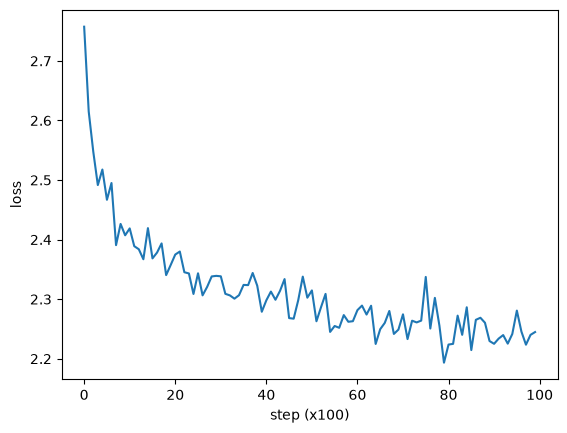

In [44]:
#lossi可视化
plt.plot(torch.tensor(lossi).view(-1, 100).mean(1))  # 每100步取平均,去掉mini-batch噪声
plt.xlabel('step (x100)')
plt.ylabel('loss')
min(lossi),max(lossi),lossi[-1]

In [45]:
@torch.no_grad()
def split_loss(X_split, Y_split):
    emb = C[X_split]
    emb_flat = emb.reshape(emb.shape[0], -1)
    h = torch.tanh(emb_flat @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y_split)
    return loss.item()

print(f"train loss: {split_loss(X_train, Y_train):.4f}")
print(f"dev loss:   {split_loss(X_dev, Y_dev):.4f}")

train loss: 2.2469
dev loss:   2.2580


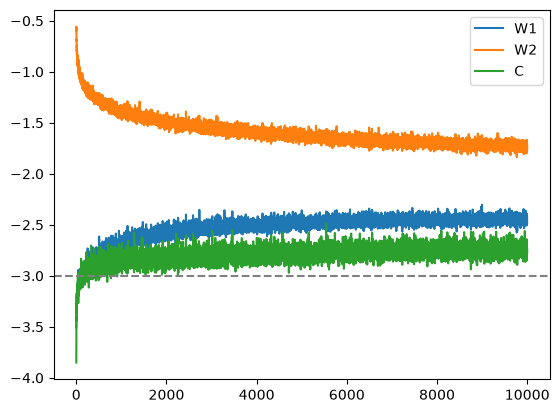

In [46]:
plt.plot(ud_w1, label='W1')
plt.plot(ud_w2, label='W2')
plt.plot(ud_c, label='C')
plt.legend()
plt.axhline(-3, color='gray', linestyle='--')  # 参考线,理想值附近

(array([686., 232., 183., 123., 137., 105.,  81.,  88.,  89.,  72.,  99.,
         73.,  98.,  92.,  92.,  84.,  71., 113.,  86.,  82.,  80.,  96.,
         83.,  97.,  87.,  58.,  95.,  87.,  93.,  84., 107.,  87.,  95.,
         87.,  70.,  87.,  71.,  75.,  62.,  83.,  84.,  80.,  97.,  88.,
        115., 131., 145., 199., 274., 817.]),
 array([-9.99998748e-01, -9.59998786e-01, -9.19998825e-01, -8.79998863e-01,
        -8.39998901e-01, -7.99998939e-01, -7.59998918e-01, -7.19998956e-01,
        -6.79998994e-01, -6.39999032e-01, -5.99999070e-01, -5.59999108e-01,
        -5.19999146e-01, -4.79999185e-01, -4.39999223e-01, -3.99999261e-01,
        -3.59999299e-01, -3.19999337e-01, -2.79999375e-01, -2.39999413e-01,
        -1.99999452e-01, -1.59999490e-01, -1.19999528e-01, -7.99995661e-02,
        -3.99995446e-02,  4.17232513e-07,  4.00003791e-02,  8.00003409e-02,
         1.20000303e-01,  1.60000265e-01,  2.00000226e-01,  2.40000188e-01,
         2.80000150e-01,  3.20000112e-01,  3.60000

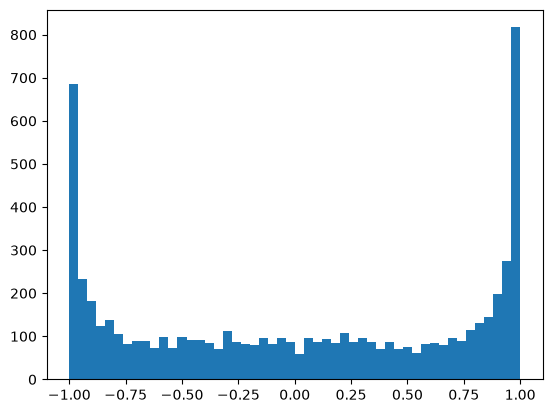

In [47]:
plt.hist(snapshot_a1[iters-1].flatten(), bins=50)

In [70]:
count=(W2>0).sum().item()
W2.shape[0]*W2.shape[1],count


(5400, 2663, 0)